# Volatility Clustering Analysis: ACF/PACF of Returns and Squared Returns

**Dataset:** Nifty 50 daily OHLCV (2014–2024), with open-to-close simple and log returns already computed.

**Goal:** Determine whether returns exhibit linear autocorrelation, and whether squared/absolute returns show the "volatility clustering" signature that motivates ARCH/GARCH-style volatility models.

**Contents:**
1. Load data
2. Construct squared and absolute returns
3. Visualize returns and squared returns over time
4. ACF and PACF of returns
5. ACF and PACF of squared and absolute returns
6. Ljung-Box test for joint significance of autocorrelation
7. Interpretation and next steps


## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

pd.set_option('display.float_format', lambda x: f'{x:.6f}')
plt.rcParams['figure.dpi'] = 110


In [2]:
df = pd.read_csv('cleaned_data_with_returns.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"Rows: {len(df)}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
df.head()


Rows: 2670
Date range: 2014-01-02 to 2024-12-30


,Date,Close,High,Low,Open,Volume,simple_return_o2c,log_return_o2c
0,2014-01-02,6221.149902,6358.299805,6211.299805,6301.250000,158100,-0.012712,-0.012793
1,2014-01-03,6211.149902,6221.700195,6171.250000,6194.549805,139000,0.002680,0.002676
2,2014-01-06,6191.450195,6224.700195,6170.250000,6220.850098,118300,-0.004726,-0.004737
3,2014-01-07,6162.250000,6221.500000,6144.750000,6203.899902,138600,-0.006714,-0.006736
4,2014-01-08,6174.600098,6192.100098,6160.350098,6178.049805,146900,-0.000558,-0.000559


## 2. Construct Squared and Absolute Returns

Raw returns can be uncorrelated while still having *dependent magnitudes* — a large move today can be followed by another large move tomorrow, regardless of direction. Squaring (or taking the absolute value of) returns removes the sign and isolates this magnitude dependence, which is the standard way to check for **volatility clustering**.

We use `log_return_o2c` (open-to-close log return) as the base return series throughout this notebook.

In [3]:
df['squared_return'] = df['log_return_o2c'] ** 2
df['abs_return'] = df['log_return_o2c'].abs()

ret = df['log_return_o2c'].dropna()
sq_ret = ret ** 2
abs_ret = ret.abs()

print(f"N observations used: {len(ret)}")
ret.describe()


N observations used: 2670


count   2670.000000
mean      -0.000741
std        0.008486
min       -0.070616
25%       -0.004833
50%       -0.000511
75%        0.003684
max        0.088986
Name: log_return_o2c, dtype: float64

## 3. Returns and Squared Returns Over Time

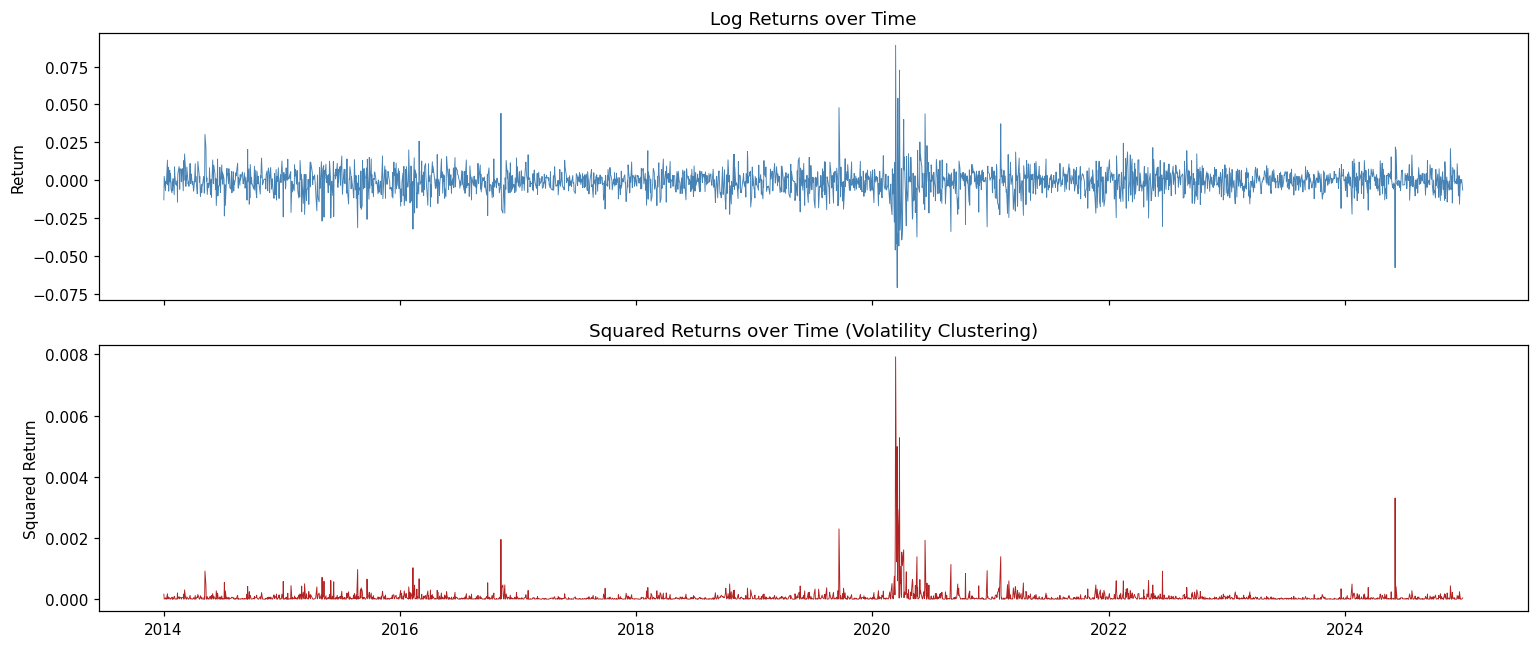

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(df['Date'], df['log_return_o2c'], lw=0.6, color='steelblue')
axes[0].set_title('Log Returns over Time')
axes[0].set_ylabel('Return')

axes[1].plot(df['Date'], df['squared_return'], lw=0.6, color='firebrick')
axes[1].set_title('Squared Returns over Time (Volatility Clustering)')
axes[1].set_ylabel('Squared Return')

plt.tight_layout()
plt.savefig('returns_timeseries.png', dpi=140)
plt.show()


**What to look for:** in the top panel, large and small moves in raw returns look scattered fairly randomly through time. In the bottom panel, spikes in squared returns visibly *cluster* together (e.g. around COVID-19 in early 2020) — periods of high volatility persist for a while rather than being isolated single-day events. This is the visual definition of volatility clustering.

## 4. ACF and PACF — Concepts

**ACF (Autocorrelation Function)** at lag $k$ measures the correlation between $x_t$ and $x_{t-k}$:

$$\rho_k = \frac{\text{Cov}(x_t, x_{t-k})}{\text{Var}(x_t)}$$

This captures the **total** correlation at each lag, including indirect effects passed through intermediate lags.

**PACF (Partial Autocorrelation Function)** at lag $k$ measures the correlation between $x_t$ and $x_{t-k}$ *after removing* the effects of lags $1$ through $k-1$. It isolates the direct relationship at each lag, which is why it's used to identify the order of an AR process — PACF cuts off sharply after the true lag order, while ACF decays gradually.

We compute both on:
- **Raw returns** — to check for linear predictability (a market-efficiency style question)
- **Squared/absolute returns** — to check for volatility clustering (dependence in magnitude, independent of direction)


## 5. ACF/PACF of Raw Returns

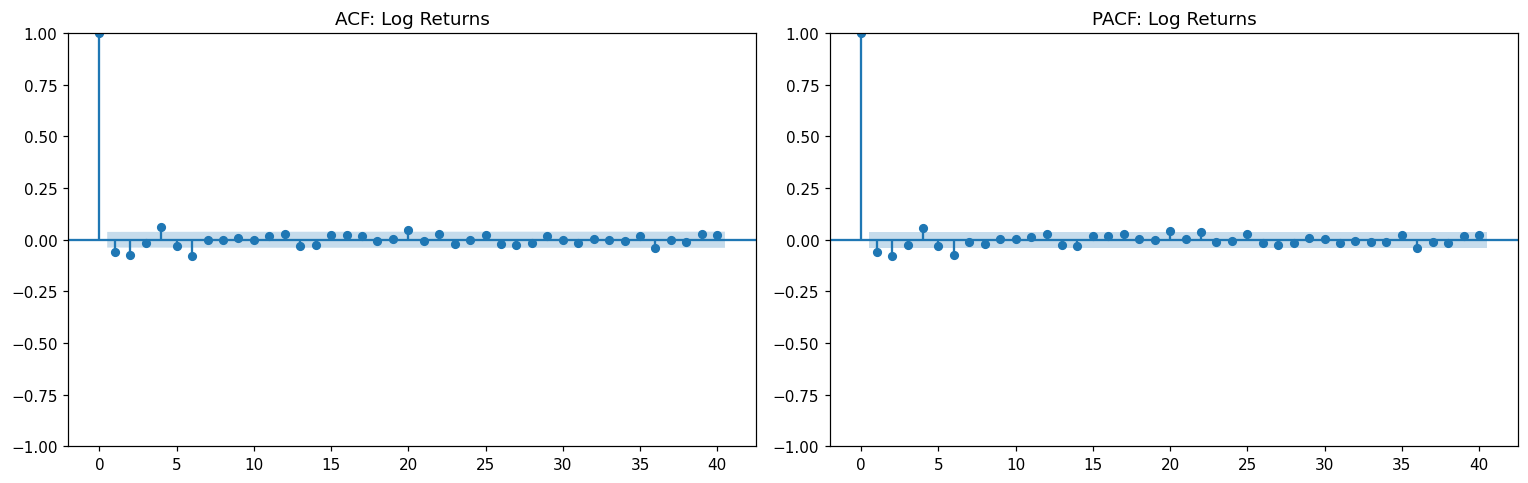

In [5]:
nlags = 40

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_acf(ret, lags=nlags, ax=axes[0], title='ACF: Log Returns')
plot_pacf(ret, lags=nlags, ax=axes[1], title='PACF: Log Returns', method='ywm')
plt.tight_layout()
plt.savefig('acf_pacf_returns_only.png', dpi=140)
plt.show()


**Reading this:** most bars sit inside the shaded 95% confidence band and decay to near zero almost immediately. This is consistent with returns being close to linearly unpredictable (a mild form of market efficiency) — there isn't a strong, exploitable linear pattern from one day's return to the next.

## 6. ACF/PACF of Squared and Absolute Returns

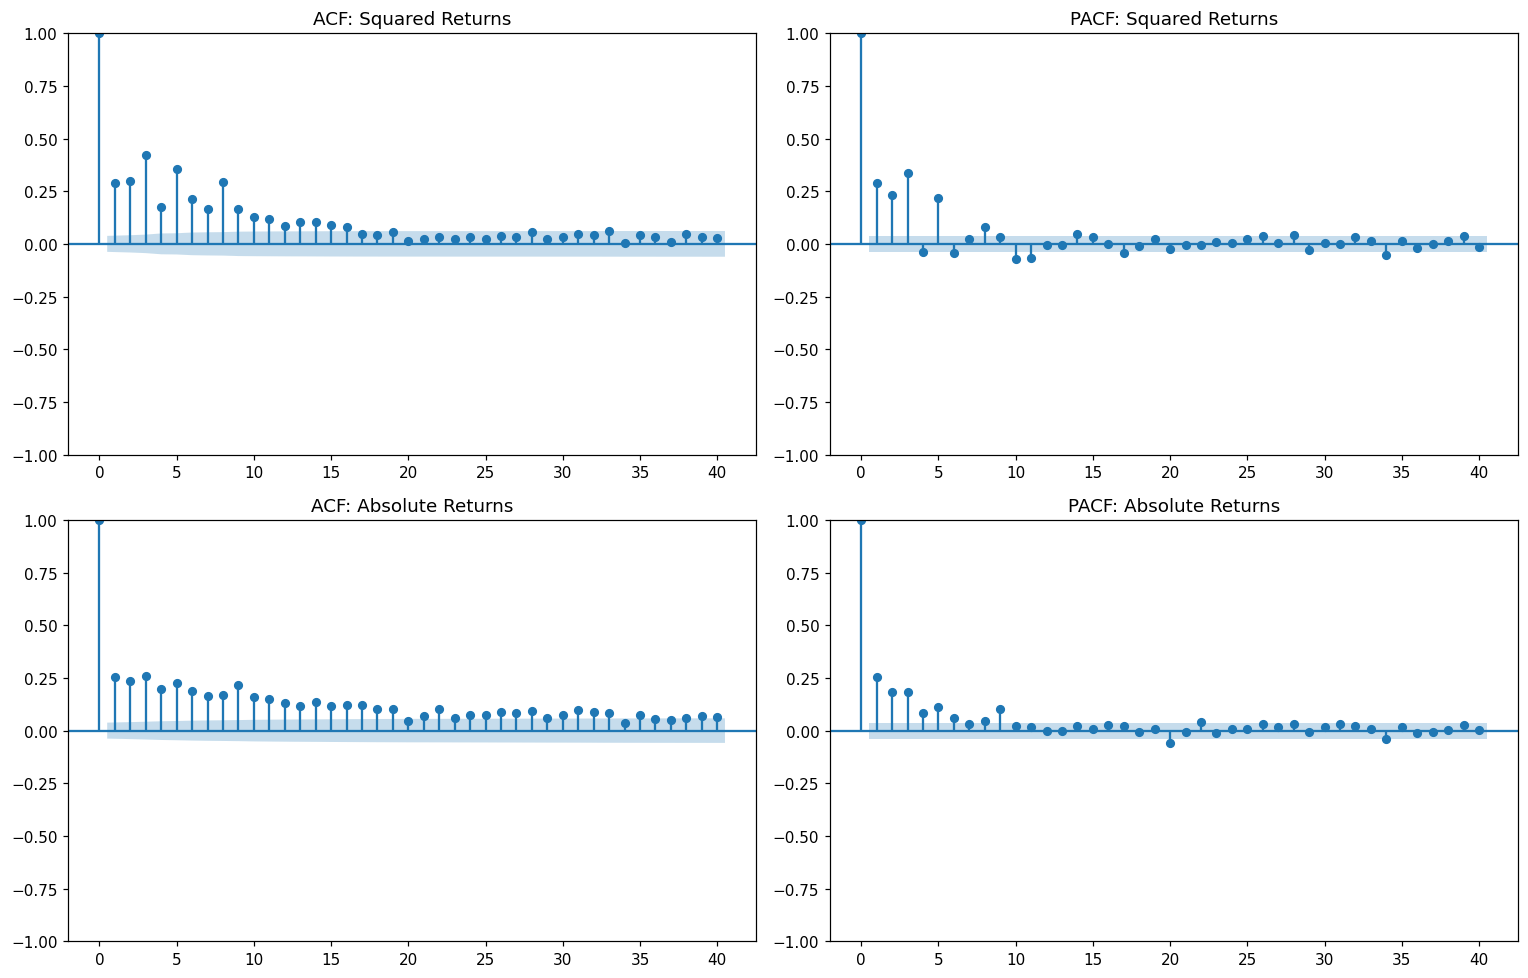

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

plot_acf(sq_ret, lags=nlags, ax=axes[0, 0], title='ACF: Squared Returns')
plot_pacf(sq_ret, lags=nlags, ax=axes[0, 1], title='PACF: Squared Returns', method='ywm')
plot_acf(abs_ret, lags=nlags, ax=axes[1, 0], title='ACF: Absolute Returns')
plot_pacf(abs_ret, lags=nlags, ax=axes[1, 1], title='PACF: Absolute Returns', method='ywm')

plt.tight_layout()
plt.savefig('acf_pacf_squared_abs_returns.png', dpi=140)
plt.show()


**Reading this:** unlike raw returns, the ACF of squared (and absolute) returns is strongly positive and decays *slowly*, remaining above the confidence band for 20+ lags. The PACF shows a large spike at lag 1 with several more significant lags before tapering off.

This pattern — slow ACF decay plus a large but not instantly-vanishing PACF — is the classic signature that motivates conditional heteroskedasticity models:
- A sharp PACF cutoff after lag 1 alone would suggest a simple ARCH(1).
- The slower decay observed here suggests volatility shocks are persistent, which is better captured by a **GARCH(1,1)**-type model than a pure ARCH model.


## 7. Ljung-Box Test

ACF/PACF plots are useful visually, but the Ljung-Box test gives a formal hypothesis test for autocorrelation up to a given lag $k$:

$$H_0: \rho_1 = \rho_2 = \dots = \rho_k = 0 \quad \text{(no autocorrelation up to lag } k\text{)}$$

Test statistic:

$$Q = n(n+2)\sum_{i=1}^{k}\frac{\hat\rho_i^2}{n-i}$$

Under $H_0$, $Q$ is approximately $\chi^2$-distributed with $k$ degrees of freedom. A small p-value rejects the null of "no autocorrelation," confirming that a pattern seen in the ACF plot is statistically real rather than noise.

We test at lags 5, 10, and 20 to check joint significance over multiple horizons rather than relying on any single lag, since individual lags can appear significant by chance even under white noise.

In [7]:
lb_ret = acorr_ljungbox(ret, lags=[5, 10, 20], return_df=True)
lb_sq = acorr_ljungbox(sq_ret, lags=[5, 10, 20], return_df=True)
lb_abs = acorr_ljungbox(abs_ret, lags=[5, 10, 20], return_df=True)

print("Ljung-Box: Log Returns")
display(lb_ret)

print("\nLjung-Box: Squared Returns")
display(lb_sq)

print("\nLjung-Box: Absolute Returns")
display(lb_abs)


Ljung-Box: Log Returns


,lb_stat,lb_pvalue
5,37.581896,0.000000
10,53.874505,0.000000
20,71.018848,0.000000



Ljung-Box: Squared Returns


,lb_stat,lb_pvalue
5,1355.699712,0.000000
10,1895.259565,0.000000
20,2069.335725,0.000000



Ljung-Box: Absolute Returns


,lb_stat,lb_pvalue
5,740.296702,0.000000
10,1177.213233,0.000000
20,1547.655726,0.000000


## 8. Export Computed Series and Tables

Save the augmented dataset (with squared/absolute returns), the full ACF/PACF value tables (with 95% confidence bounds), and the Ljung-Box results for further reference.

In [8]:
acf_ret_vals, acf_ret_ci = acf(ret, nlags=nlags, alpha=0.05)
pacf_ret_vals, pacf_ret_ci = pacf(ret, nlags=nlags, alpha=0.05, method='ywm')
acf_sq_vals, acf_sq_ci = acf(sq_ret, nlags=nlags, alpha=0.05)
pacf_sq_vals, pacf_sq_ci = pacf(sq_ret, nlags=nlags, alpha=0.05, method='ywm')
acf_abs_vals, acf_abs_ci = acf(abs_ret, nlags=nlags, alpha=0.05)
pacf_abs_vals, pacf_abs_ci = pacf(abs_ret, nlags=nlags, alpha=0.05, method='ywm')

acf_pacf_table = pd.DataFrame({
    'lag': range(nlags + 1),
    'acf_return': acf_ret_vals,
    'acf_return_ci_low': acf_ret_ci[:, 0],
    'acf_return_ci_high': acf_ret_ci[:, 1],
    'pacf_return': pacf_ret_vals,
    'pacf_return_ci_low': pacf_ret_ci[:, 0],
    'pacf_return_ci_high': pacf_ret_ci[:, 1],
    'acf_squared_return': acf_sq_vals,
    'acf_squared_return_ci_low': acf_sq_ci[:, 0],
    'acf_squared_return_ci_high': acf_sq_ci[:, 1],
    'pacf_squared_return': pacf_sq_vals,
    'pacf_squared_return_ci_low': pacf_sq_ci[:, 0],
    'pacf_squared_return_ci_high': pacf_sq_ci[:, 1],
    'acf_abs_return': acf_abs_vals,
    'acf_abs_return_ci_low': acf_abs_ci[:, 0],
    'acf_abs_return_ci_high': acf_abs_ci[:, 1],
    'pacf_abs_return': pacf_abs_vals,
    'pacf_abs_return_ci_low': pacf_abs_ci[:, 0],
    'pacf_abs_return_ci_high': pacf_abs_ci[:, 1],
})

lb_ret_export = lb_ret.reset_index().rename(columns={'index': 'lag'})
lb_ret_export['series'] = 'log_return'
lb_sq_export = lb_sq.reset_index().rename(columns={'index': 'lag'})
lb_sq_export['series'] = 'squared_return'
lb_abs_export = lb_abs.reset_index().rename(columns={'index': 'lag'})
lb_abs_export['series'] = 'abs_return'
ljung_box_table = pd.concat([lb_ret_export, lb_sq_export, lb_abs_export], ignore_index=True)

df.to_csv('returns_with_squared_returns.csv', index=False)
acf_pacf_table.to_csv('acf_pacf_table.csv', index=False)
ljung_box_table.to_csv('ljung_box_results.csv', index=False)

print("Saved: returns_with_squared_returns.csv, acf_pacf_table.csv, ljung_box_results.csv")


Saved: returns_with_squared_returns.csv, acf_pacf_table.csv, ljung_box_results.csv


/tmp/ipykernel_121/2763624310.py:1: FutureWarning: acf currently returns a plain tuple whose length depends on the qstat and alpha arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an AcfResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  acf_ret_vals, acf_ret_ci = acf(ret, nlags=nlags, alpha=0.05)
/tmp/ipykernel_121/2763624310.py:3: FutureWarning: acf currently returns a plain tuple whose length depends on the qstat and alpha arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an AcfResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  acf_sq_vals, acf_sq_ci = acf(sq_ret, nlags=nlags, alpha=0.05)
/tmp/ipykernel_121/2763624310.py:5: FutureWarning: acf currently returns a plain tuple whose length depends on 

## 9. Summary of Findings

| Series | ACF/PACF pattern | Ljung-Box (p-value) | Interpretation |
|---|---|---|---|
| Log returns | Decays to ~0 almost immediately; mostly inside confidence band | Small but non-trivial (rejects white noise, weakly) | Returns are close to linearly unpredictable — consistent with market efficiency at the linear level |
| Squared returns | Strong, slowly-decaying ACF; large PACF spike at lag 1, tapering over several lags | ≈ 0 at all tested lags | Strong, statistically confirmed volatility clustering |
| Absolute returns | Same pattern as squared returns | ≈ 0 at all tested lags | Confirms clustering is not an artifact of the squaring transform |

**Conclusion:** Returns themselves carry little linear predictability, but the *magnitude* of returns is highly persistent — large moves are followed by more large moves (in either direction), and this persists over multiple weeks (slow ACF decay). This is the standard empirical justification for modeling conditional volatility explicitly.